# Beyond BLAST: generalized window functions

This notebook starts from the derivation in [equations.tex](sheet/equations.tex) and rewrites the window function in its most general form before specializing to the BLAST/N5K cases.

## Generalized window function

The generalized window function is
$$W_l^A(k,\chi)=f^A(\chi)j_l\!\left(k\,r(\chi)\right)$$

where $f^A(\chi)$ collects the tracer-specific weights and $r(\chi)$ is the radial distance associated with the background geometry. In a flat background, $r(\chi)=\chi$, so the expression reduces to the form used in BLAST.

The point of writing the window this way is that all observable-specific physics is isolated in $f^A(\chi)$, while the spherical Bessel factor keeps the full 3D radial dependence.

### Example: galaxy density

For a galaxy density tracer, the weight is
$$f^{\rm den}(\chi)=\frac{H(z)}{c}b(z)n(z)D(z)$$

so the corresponding generalized window is
$$W_l^{\rm den}(k,\chi)=\frac{H(z)}{c}b(z)n(z)D(z)\,j_l\!\left(k\,r(\chi)\right)$$

This is the basic object that later feeds the Hankel transform and, ultimately, the angular power spectrum integral.

## Hankel transform of the window

To move from a line-of-sight window to a spherical representation, we project the generalized window onto a second spherical Bessel basis. The natural object is the Hankel transform
$$\widetilde{W}_l^{A}(k,k') \equiv \int_0^{\infty} d\chi\, \chi^2\, W_l^{A}(k,\chi)\, j_l(k'\chi)$$

Using the generalized form $W_l^{A}(k,\chi)=f^A(\chi)j_l\!\left(k\,r(\chi)\right)$, this becomes
$$\widetilde{W}_l^{A}(k,k') = \int_0^{\infty} d\chi\, \chi^2\, f^A(\chi)\, j_l\!\left(k\,r(\chi)\right) j_l(k'\chi)$$

In a flat background, where $r(\chi)=\chi$, the transform simplifies to
$$\widetilde{W}_l^{A}(k,k') = \int_0^{\infty} d\chi\, \chi^2\, f^A(\chi)\, j_l(k\chi) j_l(k'\chi)$$

This is the spherical analogue of the standard BLAST window: the original tracer weight is now embedded inside a radial kernel that couples two wavenumbers.

## Spherical BLAST kernel

Once the two window functions have been Hankel transformed, the spherical correlation function is obtained by integrating over the internal wavenumber,
$$S_l^{AB}(k_1,k_2) = N_l^{AB} \int dk\, k^2\, P^{AB}(k,\chi,\chi')\, \widetilde{W}_l^{A}(k,k_1)\, \widetilde{W}_l^{B}(k,k_2)$$

If the matter power spectrum is written in separable growth form,
$$P^{AB}(k,\chi,\chi') = D(\chi)D(\chi')P_{\rm lin}^{AB}(k)$$

then the growth factors are absorbed into $f^A(\chi)$ and $f^B(\chi')$, and the spherical kernel becomes
$$S_l^{AB}(k_1,k_2) = N_l^{AB} \int dk\, k^2\, P_{\rm lin}^{AB}(k)\, \widetilde{W}_l^{A}(k,k_1)\, \widetilde{W}_l^{B}(k,k_2)$$

For galaxy clustering, the tracer weight is
$$f^{\rm den}(\chi)=\frac{H(z)}{c}b(z)n(z)D(z)$$

so the corresponding spherical kernel is controlled by the double-Bessel integral
$$\widetilde{W}_l^{\rm den}(k,k') = \int_0^{\infty} d\chi\, \chi^2\, \frac{H(z)}{c}b(z)n(z)D(z)\, j_l(k\chi)j_l(k'\chi)$$

This is the object that can be tabulated once and then reused for the different observable combinations in the same way as in the BLAST notebook.

In [1]:
using Pkg
Pkg.activate("blast_code")
Pkg.resolve()
Pkg.instantiate()
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")

  Activating project at `~/Desktop/cosmo/blast_code`
  No Changes to `~/Desktop/cosmo/blast_code/Project.toml`
  No Changes to `~/Desktop/cosmo/blast_code/Manifest.toml`


Main.blast_tutorials

In [2]:
using NPZ
using DataInterpolations
using Interpolations
using FastChebInterp
using BenchmarkTools
using Plots
using QuadGK
using LaTeXStrings
using Tullio
using LoopVectorization
using LinearAlgebra
using Revise
using SpecialFunctions
using .Blast
using .blast_tutorials

In [3]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy")
χ_b = npzread("blast_code/data/background/chi.npy")
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b);

In [4]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z = pk_dict["z"];

In [5]:
#Interpolating the power spectrum
#Linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))

InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm = scale(InterpPmm, (x, y))
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())

#Non-linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())

#Callables
power_spectrum(k, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));

## Practical decomposition recipe

To decompose $S_l^{AB}$ in the BLAST style, sample the power spectrum on the Chebyshev $k$ grid first. In this notebook, `Pvals` means the array of sampled values
$$P_{\rm vals}[n,j,i] = P^{AB}\!\left(k_n,\chi_j,\chi_j R_i\right)$$

with shape $(n_k,n_\chi,n_R)$. Once that array is built, the rest is the same BLAST pattern: FFT/DCT along the $k$ axis, precompute the spherical Bessel integrals, then contract the two tensors.

In [13]:
ℓ = Blast.ℓ
nχ = 96
x_min = 26
x_max = 7000
χ = LinRange(x_min, x_max, nχ)
R = chebpoints(nx, -1, 1)
R = reverse(R[R.>0])
nR = length(R)
kmax = 200/13
kmin = 2.5/x_max
n_cheb = 119
β = 2 #0 per CL, 2 per CC, -2 per LL
k_cheb = chebpoints(n_cheb, log10(kmin), log10(kmax))
k1 = first(k_cheb)
k2 = first(k_cheb)
N = 2^(15)+1

32769

### Updated precomputation of $\tilde T_\ell$
The extra spherical-Bessel factors that depend on the external wavenumbers can be pulled outside the $k$-integral, so the reusable BLAST piece is still the two-Bessel object computed by `compute_T̃`.
For a fixed pair $(k_1,k_2)$, the generalized kernel is therefore the old tensor dressed by
$$j_\ell(k_1\chi)\,j_\ell(k_2\chi')$$
so the precomputation step stays the same in structure, but the final contraction uses the dressed tensor.

In [14]:
# Compute T̃ for each ℓ value
T_LL = zeros(length(ℓ), length(χ), length(R), n_cheb + 1)
T_CL = zeros(length(ℓ), length(χ), length(R), n_cheb + 1)
T_CC = zeros(length(ℓ), length(χ), length(R), n_cheb + 1)
for i in eachindex(ℓ)
    T_LL[i,:,:,:] = Blast.compute_T̃_general(ℓ[i], χ, R, kmin, kmax, -2, k1, k2; n_cheb=n_cheb, N=N)
    T_CL[i,:,:,:] = Blast.compute_T̃_general(ℓ[i], χ, R, kmin, kmax, 0, k1, k2; n_cheb=n_cheb, N=N)
    T_CC[i,:,:,:] = Blast.compute_T̃_general(ℓ[i], χ, R, kmin, kmax, 2, k1, k2; n_cheb=n_cheb, N=N)
    println("done", [i], ", now", [i+1])
end

done[1], now[2]
done[2], now[3]
done[3], now[4]
done[4], now[5]
done[5], now[6]
done[6], now[7]
done[7], now[8]
done[8], now[9]
done[9], now[10]
done[10], now[11]
done[11], now[12]
done[12], now[13]
done[13], now[14]
done[14], now[15]
done[15], now[16]
done[16], now[17]
done[17], now[18]
done[18], now[19]
done[19], now[20]
done[20], now[21]
done[21], now[22]
done[22], now[23]


In [15]:
print("Shape of the precomputed T̃_LL: ", size(T_LL), "\n")
print("Shape of the precomputed T̃_CL: ", size(T_CL), "\n")
print("Shape of the precomputed T̃_CC: ", size(T_CC), "\n")

Shape of the precomputed T̃_LL: (22, 96, 48, 120)
Shape of the precomputed T̃_CL: (22, 96, 48, 120)
Shape of the precomputed T̃_CC: (22, 96, 48, 120)


In [16]:
cosmo = Blast.FlatΛCDM()
z_range = z_of_χ.(χ)
bgrid = Blast.CosmologicalGrid(z_range = z_range)
bg = Blast.BackgroundQuantities(Hz_array = zeros(length(z_range)), χz_array = Array(χ));

In [17]:
cheb_coeff = zeros(nχ, nR, n_cheb + 1)
vals = power_spectrum.(10 .^ k_cheb, χ[1], χ[1] * R[1])
plan = Blast.plan_fft(vals)

for i in 1:nR
    for j in 1:nχ
        vals = power_spectrum.(10 .^ k_cheb, χ[j], χ[j] * R[i])
        cheb_coeff[j, i, :] = Blast.fast_chebcoefs(vals, plan)
    end
end
println(size(cheb_coeff))
println(size(T_LL))

(96, 48, 120)
(22, 96, 48, 120)


In [18]:
w_LL = Blast.w_ell_tullio(cheb_coeff, T_LL)
w_CL = Blast.w_ell_tullio(cheb_coeff, T_CL)
w_CC = Blast.w_ell_tullio(cheb_coeff, T_CC);

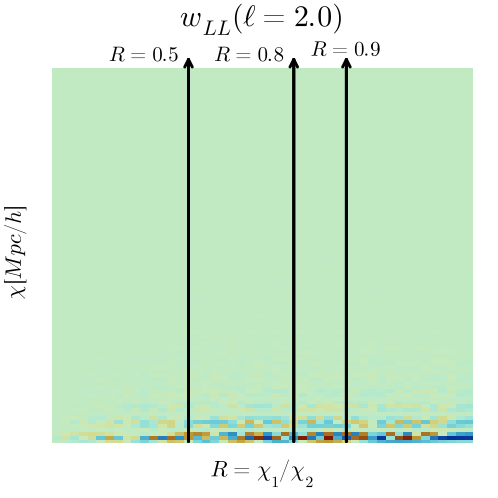

In [19]:
heatmap(1:48, χ, w_LL[1,:,:]./maximum(w_LL[1,:,:]), size = (500,500), title=L"w_{LL}(ℓ=2.0)", 
    c =:roma , xlabel=L"R=\chi_1/\chi_2",ylabel=L"\chi[Mpc/h]", legend=:none,
    yguidefontsize=15, xguidefontsize=15 , titlefontsize=20)

plot!([16,16],[26, 7200],arrow=true,color=:black,linewidth=3,label=nothing, size = (500,500)) 
annotate!(11, 7300, text(L"R=0.5",14), :black)
#annotate!(16, -200,text(L"0.5",10), :black)

plot!([28,28],[26, 7200],arrow=true,color=:black,linewidth=3,label=nothing, size = (500,500)) 
annotate!(23, 7300, text(L"R=0.8",14), :black)
#annotate!(28, -200, text(L"0.8",10), :black)

plot!([34,34],[26, 7200],arrow=true,color=:black,linewidth=3,label=nothing,axis=([], false), size = (500,500)) 
annotate!(34, 7400, text(L"R=0.9",14), :black)

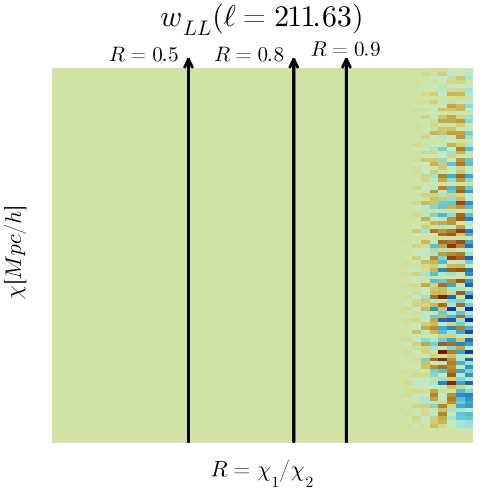

In [20]:
heatmap(1:48, χ, w_LL[22,:,:]./maximum(w_LL[22,:,:]), size = (500,500), title=L"w_{LL}(ℓ=211.63)",
    legend = :none, c =:roma , xlabel=L"R=\chi_1/\chi_2",ylabel=L"\chi[Mpc/h]",
    yguidefontsize=15, xguidefontsize=15 , titlefontsize=20)

plot!([16,16],[26, 7200],arrow=true,color=:black,linewidth=3,label="R=0.5", size = (500,500)) 
annotate!(11, 7300, text(L"R=0.5",14), :black)
#annotate!(16, -200,text(L"0.5",10), :black)

plot!([28,28],[26, 7200],arrow=true,color=:black,linewidth=3,label="R=0.5", size = (500,500)) 
annotate!(23, 7300, text(L"R=0.8",14), :black)
#annotate!(28, -200, text(L"0.8",10), :black)

plot!([34,34],[26, 7200],arrow=true,color=:black,linewidth=3,label="R=0.5",axis=([], false), size = (500,500)) 
annotate!(34, 7400, text(L"R=0.9",14), :black)

In [21]:
# Load N5K n(z), needed to compute lensing and clustering kernels
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")

Dict{String, Array{Float64}} with 4 entries:
  "dNdz_cl" => [9.51877e-8 1.11093e-13 … 5.97529e-61 6.25179e-67; 1.246e-7 1.56…
  "z_sh"    => [0.00583333, 0.00757837, 0.00932341, 0.0110684, 0.0128135, 0.014…
  "dNdz_sh" => [0.106801 1.52148e-9 … 6.04656e-24 7.57113e-34; 0.111443 1.76706…
  "z_cl"    => [0.00583333, 0.00757837, 0.00932341, 0.0110684, 0.0128135, 0.014…

In [22]:
GalKernels = Blast.GalaxyKernel(10, length(bgrid.z_range))
Blast.compute_kernel!(n5k_bins["dNdz_cl"]',  n5k_bins["z_cl"], GalKernels, bgrid, bg, cosmo)

In [31]:
ShearKernels = Blast.ShearKernel(4, length(bgrid.z_range))
Blast.compute_kernel!(n5k_bins["dNdz_sh"]', n5k_bins["z_sh"], ShearKernels, bgrid, bg, cosmo)

In [24]:
#Loading the N5K pre-computed kernel to check that they match!
W = npzread("blast_code/data/kernels_fullwidth.npz")

Dict{String, Array{Float64}} with 6 entries:
  "chi_cl"     => [25.9606, 33.7127, 41.4584, 49.1976, 56.9303, 64.6566, 72.376…
  "kernels_sh" => [6.04145e-7 7.78856e-7 … 0.0 0.0; 6.14932e-7 7.9704e-7 … 0.0 …
  "z_sh"       => [0.00583333, 0.00757837, 0.00932341, 0.0110684, 0.0128135, 0.…
  "chi_sh"     => [25.9606, 33.7127, 41.4584, 49.1976, 56.9303, 64.6566, 72.376…
  "kernels_cl" => [0.0 1.02182e-10 … 0.0 0.0; 0.0 9.54391e-17 … 0.0 0.0; … ; 0.…
  "z_cl"       => [0.00583333, 0.00757837, 0.00932341, 0.0110684, 0.0128135, 0.…

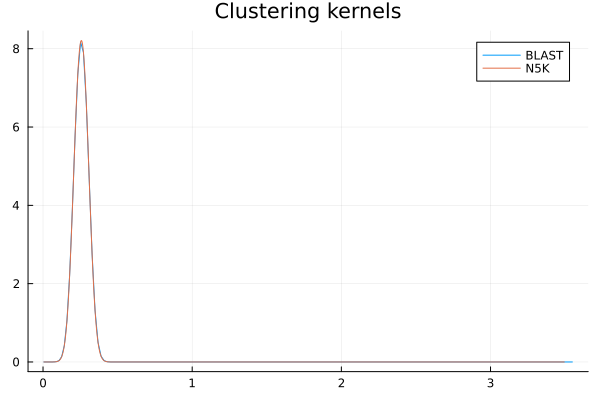

In [25]:
i_bin = 1

interp = DataInterpolations.AkimaInterpolation( W["kernels_cl"][i_bin,:], W["z_cl"], extrapolation = ExtrapolationType.Linear)
intn, _ = quadgk(x -> interp.(x), 0., 3.5)

interp = DataInterpolations.AkimaInterpolation( GalKernels.Kernel[i_bin,:], bgrid.z_range, extrapolation = ExtrapolationType.Linear)
intb, _ = quadgk(x -> interp.(x), 0., 3.5)

plot(bgrid.z_range, GalKernels.Kernel[i_bin,:]/intb, label="BLAST", title = "Clustering kernels")
plot!(W["z_cl"], W["kernels_cl"][i_bin,:]/intn, label="N5K")

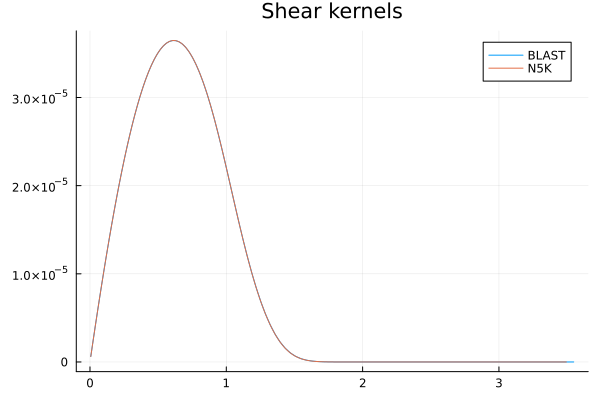

In [32]:
bin = 4

plot(bgrid.z_range, ShearKernels.Kernel[bin,:], label="BLAST", title = "Shear kernels")
plot!(W["z_sh"], W["kernels_sh"][bin,:], label="N5K")

In [33]:
K_CC, K_CL, K_LL = blast_tutorials.compute_kernels(W, χ, R)
w_χ = Blast.simpson_weight_array(nχ)
w_R = Blast.get_clencurt_weights_R_integration(2*nR+1)
pref_CC = Blast.get_ell_prefactor(GalKernels, GalKernels, ℓ)
pref_CL = Blast.get_ell_prefactor(ShearKernels, GalKernels, ℓ)
pref_LL = Blast.get_ell_prefactor(ShearKernels, ShearKernels, ℓ);

In [34]:
clustering_Cℓ = Blast.compute_Cℓ(w_CC, K_CC, bg, w_χ, w_R, pref_CC)
shear_Cℓ = Blast.compute_Cℓ(w_LL, K_LL, bg, w_χ, w_R, pref_LL)
cross_Cℓ = Blast.compute_Cℓ(w_CL, K_CL, bg, w_χ, w_R, pref_CL);

In [35]:
@benchmark Blast.compute_Cℓ(w_CC, K_CC, bg, w_χ, w_R, pref_CC)

BenchmarkTools.Trial: 2653 samples with 1 evaluation per sample.
 Range (min … max):  1.739 ms … 50.932 ms  ┊ GC (min … max): 0.00% … 0.00%
 Time  (median):     1.788 ms              ┊ GC (median):    0.00%
 Time  (mean ± σ):   1.880 ms ±  1.274 ms  ┊ GC (mean ± σ):  0.00% ± 0.00%

  ▅▄█▆▅▄▃▃▂▁▁▁▁▁                                             ▁
  █████████████████▆▆█▇▇▆▆▇▆▆▄▃▅▄▅▆▄▆▅▄▁▃▁▃▁▁▄▁▃▁▁▃▃▃▄▃▃▁▁▁▃ █
  1.74 ms      Histogram: log(frequency) by time     2.68 ms <

 Memory estimate: 17.38 KiB, allocs estimate: 4.

In [39]:
dtype = Float64
Cℓ_CC_limb = dtype.(npzread("blast_code/data/Limber/Cl_CC_limber_linear_full.npy"))
Cℓ_CL_limb =  dtype.(npzread("blast_code/data/Limber/Cl_CL_limber_linear_full.npy"))
Cℓ_LL_limb =  dtype.(npzread("blast_code/data/Limber/Cl_LL_limber_linear_full.npy"))
Cℓ_CC_limb_nl = dtype.(npzread("blast_code/data/Limber/Cl_CC_limber_nl_full.npy"))
Cℓ_CL_limb_nl = dtype.(npzread("blast_code/data/Limber/Cl_CL_limber_nl_full.npy"))
Cℓ_LL_limb_nl = dtype.(npzread("blast_code/data/Limber/Cl_LL_limber_nl_full.npy"));

In [40]:
final_clustering_Cℓ = clustering_Cℓ + Cℓ_CC_limb_nl - Cℓ_CC_limb
final_cross_Cℓ = cross_Cℓ + Cℓ_CL_limb_nl - Cℓ_CL_limb
final_shear_Cℓ = shear_Cℓ + Cℓ_LL_limb_nl - Cℓ_LL_limb;

In [42]:
### add Limber Cl's in chebyshev points for l>200
Cℓ_CC_limb = dtype.(npzread("blast_code/data/Limber/Cl_CC_limber+200_full.npy"))
Cℓ_CL_limb = dtype.(npzread("blast_code/data/Limber/Cl_CL_limber+200_full.npy"))
Cℓ_LL_limb = dtype.(npzread("blast_code/data/Limber/Cl_LL_limber+200_full.npy"))
total_Cℓ_CC = cat(final_clustering_Cℓ, Cℓ_CC_limb, dims=1)
total_Cℓ_CL = cat(final_cross_Cℓ, Cℓ_CL_limb, dims=1)
total_Cℓ_LL = cat(final_shear_Cℓ, Cℓ_LL_limb, dims=1);

In [44]:
# Interpolating to go on the same n5k grid
elle = dtype.(reverse(chebpoints(100, 2, 2000)))
ℓ_min = 2
ℓ_max = 2000

interp_Cℓ_CC = zeros(dtype, length(elle), 10, 10)  # ← ell → elle
interp_Cℓ_CL = zeros(dtype, length(elle), 10, 5)
interp_Cℓ_LL = zeros(dtype, length(elle), 5, 5)

for i in 1:10
    for j in i:10
        interpol = chebinterp(reverse(total_Cℓ_CC[:,i,j].*elle.*elle), ℓ_min, ℓ_max)
        interp_Cℓ_CC[:,i,j] = interpol.(elle) ./ (elle.*elle)  # ← ell → elle
        interp_Cℓ_CC[:,j,i] = interp_Cℓ_CC[:,i,j]
    end
end

for i in 1:10
    for j in 1:5
        interpol = chebinterp(reverse(total_Cℓ_CL[:,i,j].*elle.*elle), ℓ_min, ℓ_max)
        interp_Cℓ_CL[:,i,j] = interpol.(elle) ./ (elle.*elle)  # ← ell → elle
    end
end

for i in 1:5
    for j in i:5
        interpol = chebinterp(reverse(total_Cℓ_LL[:,i,j].*elle.*elle), ℓ_min, ℓ_max)
        interp_Cℓ_LL[:,i,j] = interpol.(elle) ./ (elle.*elle)  # ← ell → elle
        interp_Cℓ_LL[:,j,i] = interp_Cℓ_LL[:,i,j]
    end
end

In [54]:
#N5K benchmarks
dtype = Float64

benchmark_gg = npzread("blast_code/data/benchmarks_nl_full_clgg.npz")
benchmark_ll = npzread("blast_code/data/benchmarks_nl_full_clss.npz")
benchmark_gl = npzread("blast_code/data/benchmarks_nl_full_clgs.npz")

#Extracting C_ℓ
gg = dtype.(benchmark_gg["cls"])
ll = dtype.(benchmark_ll["cls"])
gl = dtype.(benchmark_gl["cls"])
ell = dtype.(benchmark_gg["ls"])

#Reshaping them into the same Blast's format
gg_reshaped = zeros( dtype, length(ell), 10, 10)
counter = 1

for i in 1:10
    for j in i:10
        gg_reshaped[:,i,j] = gg[counter, :]
        gg_reshaped[:,j,i] = gg_reshaped[:,i,j]
        counter += 1
    end
end

ll_reshaped = zeros(dtype, length(ell), 5, 5)
counter = 1

for i in 1:5
    for j in i:5
        ll_reshaped[:,i,j] = ll[counter, :]
        ll_reshaped[:,j,i] = ll_reshaped[:,i,j]
        counter += 1
    end
end

gl_reshaped = zeros( dtype, length(ell), 10, 5)
counter = 1

for i in 1:10
    for j in 1:5
        gl_reshaped[:,i,j] = gl[counter, :]
        counter += 1
    end
end

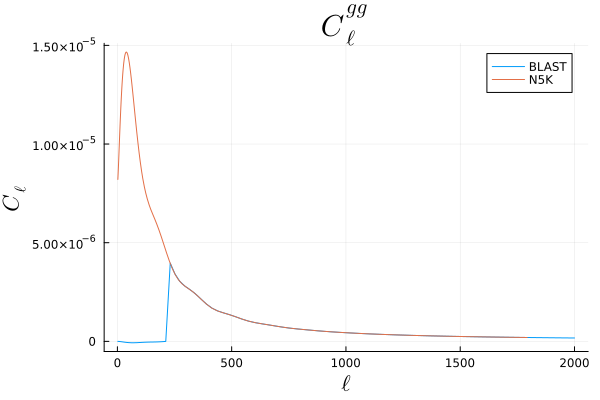

In [57]:
i = 10
j = 10
nl = 101 #set this to 103 to see up to ℓ=2000.
plot(elle[1:nl], interp_Cℓ_CC[1:nl,i,j], label="BLAST", title = L"$C_\ell^{gg}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$C_\ell$", labelfontsize=15)
plot!(ell[1:nl], gg_reshaped[1:nl,i,j], label = "N5K")

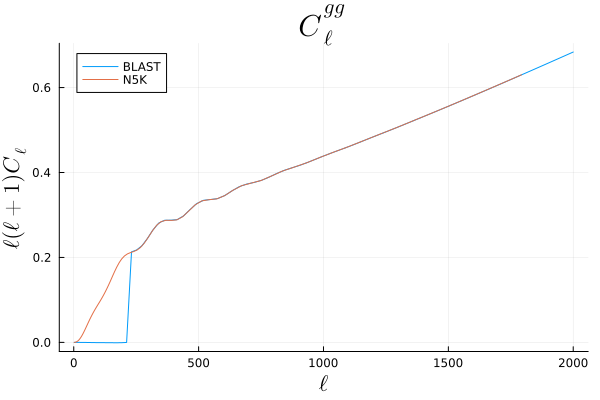

In [58]:
i = 10
j = 10
nl = 101 #set this to 103 to see up to ℓ=2000.
plot(elle[1:nl], interp_Cℓ_CC[1:nl,i,j] .* elle[1:nl] .* (elle[1:nl] .+1), label="BLAST", title = L"$C_\ell^{gg}$", titlefontsize=20, 
    xlabel=L"$\ell$", ylabel=L"$\ell(\ell+1)C_\ell$", labelfontsize=15)
plot!(ell[1:nl], gg_reshaped[1:nl,i,j] .* ell[1:nl] .* (ell[1:nl] .+1), label = "N5K")